In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("SMA.csv")
df.head()

,Q1_Gender,Q2_Living_Area,Q3_Maritial_Status,SMAQ1,SMAQ2,SMAQ3,SMAQ4,SMAQ5,SMAQ6,SMAQ7,SMAQ8,SMAQ9,SMAQ10,SMA_Scale_value,SMA_Scale (Class_Lebel)
0,1,1,2,4,5,1,3,5,2,2,4,5,3,34,2
1,1,1,2,3,2,1,5,5,1,1,2,5,1,26,2
2,2,1,2,3,2,1,1,1,1,1,1,1,1,13,1
3,1,2,2,2,5,5,2,3,1,3,4,4,1,30,2
4,1,1,2,1,4,3,1,2,1,1,1,1,1,16,1


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [4]:
# Cargar datos
df = pd.read_csv("SMA.csv")

## Random Forest

In [5]:
# Variables (features)
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])     ## eliminamos estas columnas porque contienen el resultado

# Objetivo
y = df["SMA_Scale (Class_Lebel)"]


In [6]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)        ## 20% de la muestra para el test

# Modelo
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
# Predicción
y_pred = model.predict(X_test)

# Evaluación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.87      0.93      0.90        43
           2       0.97      0.95      0.96       153
           3       0.89      0.80      0.84        10

    accuracy                           0.94       206
   macro avg       0.91      0.89      0.90       206
weighted avg       0.94      0.94      0.94       206



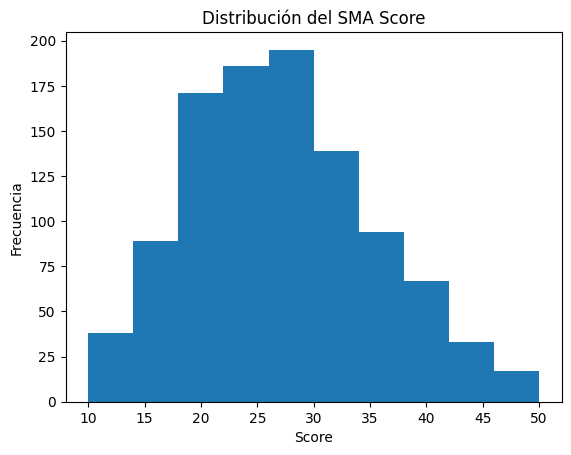

In [8]:
plt.hist(df["SMA_Scale_value"])
plt.title("Distribución del SMA Score")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.show()

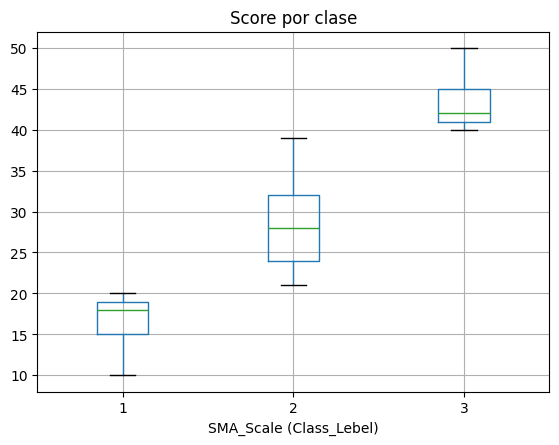

In [9]:
df.boxplot(column="SMA_Scale_value", by="SMA_Scale (Class_Lebel)")
plt.title("Score por clase")
plt.suptitle("")
plt.show()

### Random Forest

In [10]:
# Variables
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# División (IMPORTANTE: reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42                    ## random state 42: semilla aleatoria fijada en 42
)

# Modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)       ## 100 divisiones
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
# Predicciones
y_pred = model.predict(X_test)

# Evaluación
from sklearn.metrics import classification_report, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9271844660194175
              precision    recall  f1-score   support

           1       0.89      0.92      0.91        52
           2       0.94      0.96      0.95       139
           3       1.00      0.67      0.80        15

    accuracy                           0.93       206
   macro avg       0.94      0.85      0.88       206
weighted avg       0.93      0.93      0.93       206



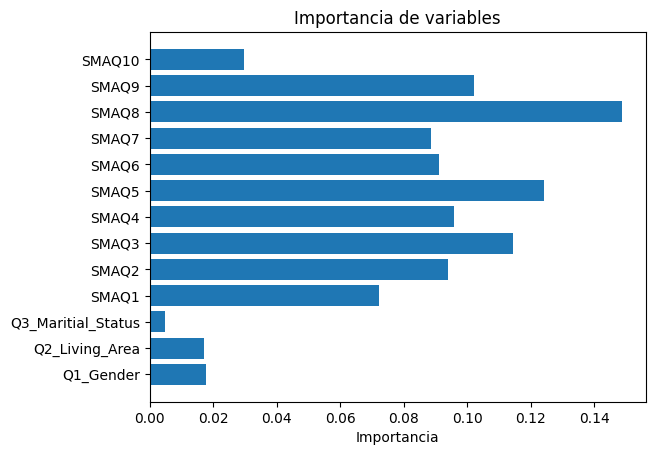

In [12]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.show()

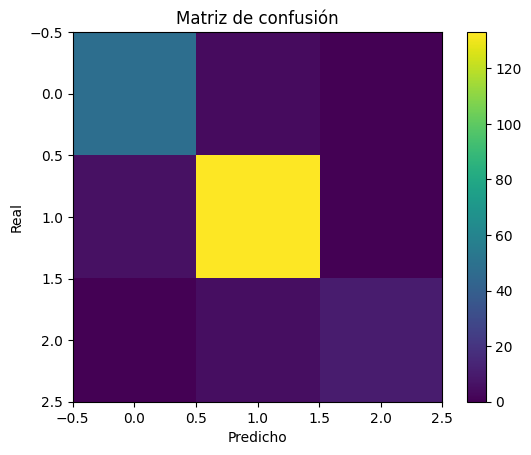

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.colorbar()
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Scores:", scores)
print("Media:", scores.mean())

Scores: [0.91262136 0.95631068 0.90776699 0.90291262 0.95121951]
Media: 0.9261662325361119


In [15]:
print(df["SMA_Scale (Class_Lebel)"].value_counts())

SMA_Scale (Class_Lebel)
2    699
1    257
3     73
Name: count, dtype: int64


## Isolation forest

In [16]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)
df["outlier"] = iso.fit_predict(X)

print(df["outlier"].value_counts())         ## 52 outliers!! (-1 significa outlier)

outlier
 1    977
-1     52
Name: count, dtype: int64


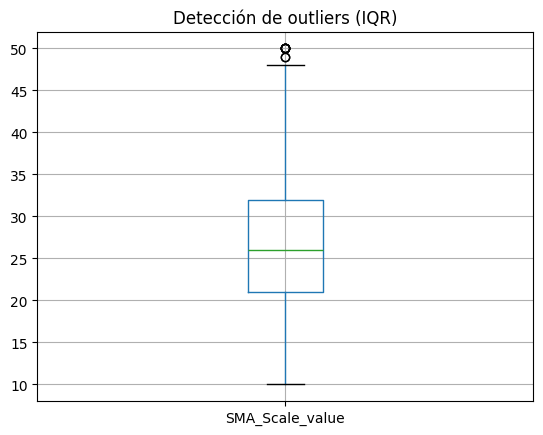

In [17]:
import matplotlib.pyplot as plt

df.boxplot(column="SMA_Scale_value")
plt.title("Detección de outliers (IQR)")
plt.show()

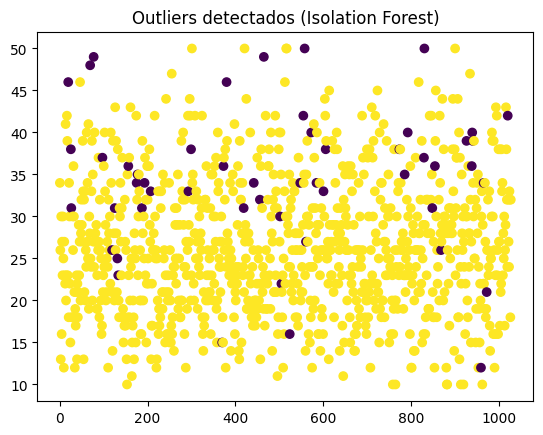

In [18]:
plt.scatter(df.index, df["SMA_Scale_value"], c=df["outlier"])
plt.title("Outliers detectados (Isolation Forest)")
plt.show()

## $z = \frac{x - \mu}{\sigma}$


In [19]:
import numpy as np

# Solo variables numéricas (ej: SMAQ + score)
numeric_cols = df.select_dtypes(include=[np.number])

z_scores = np.abs((numeric_cols - numeric_cols.mean()) / numeric_cols.std())

outliers_z = (z_scores > 3)
print(outliers_z.sum())

Q1_Gender                   0
Q2_Living_Area              0
Q3_Maritial_Status         62
SMAQ1                       0
SMAQ2                       0
SMAQ3                       0
SMAQ4                       0
SMAQ5                       0
SMAQ6                       0
SMAQ7                       0
SMAQ8                       0
SMAQ9                       0
SMAQ10                     44
SMA_Scale_value             0
SMA_Scale (Class_Lebel)     0
outlier                    52
dtype: int64


## IQR


QR (muy usado en trabajos académicos)
Basado en percentiles (no depende de distribución)

Fórmula clave
IQR = Q3 − Q1
Outlier si:
< Q1 − 1.5·IQR

Q3 + 1.5·IQR

In [20]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print(outliers_iqr.sum())

Q1_Gender                    0
Q2_Living_Area               0
Q3_Maritial_Status          62
SMAQ1                        0
SMAQ2                      119
SMAQ3                        0
SMAQ4                        0
SMAQ5                        0
SMAQ6                        0
SMAQ7                        0
SMAQ8                        0
SMAQ9                        0
SMAQ10                     225
SMA_Scale_value              9
SMA_Scale (Class_Lebel)    330
outlier                     52
dtype: int64


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Cargar datos
df = pd.read_csv("SMA.csv")

# Variables
X = df.drop(columns=["SMA_Scale (Class_Lebel)"])
y = df["SMA_Scale (Class_Lebel)"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Diccionario de modelos
models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

# Entrenar y evaluar
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

# Mostrar resultados
for model, acc in results.items():
    print(f"{model}: {acc:.3f}")

Random Forest: 1.000
Logistic Regression: 1.000
SVM: 0.990
Decision Tree: 1.000
KNN: 0.976


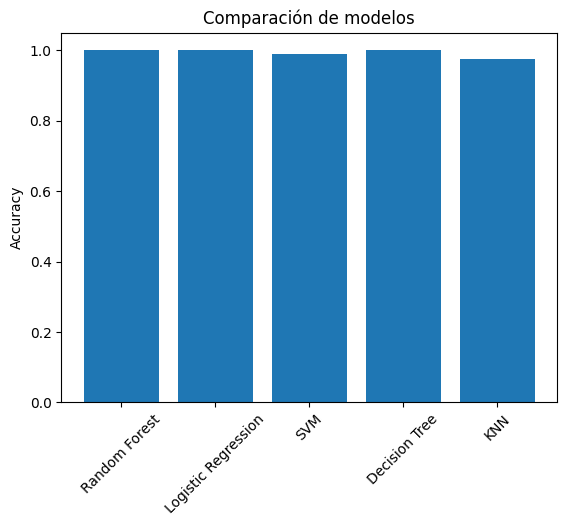

In [22]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Comparación de modelos")
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## SVM con kernel lineal y RBF?

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC

# Cargar datos
df = pd.read_csv("SMA.csv")

X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
# escalado
from sklearn.preprocessing import StandardScaler            
from sklearn.pipeline import Pipeline

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf'))
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================
# SVM LINEAL
# ==========================
svm_linear = SVC(kernel='linear')

scores_linear = cross_val_score(
    svm_linear, X, y,
    cv=cv,
    scoring='accuracy'
)

print("SVM Lineal:", scores_linear.mean())

# ==========================
# SVM RBF
# ==========================
svm_rbf = SVC(kernel='rbf')

scores_rbf = cross_val_score(
    svm_rbf, X, y,
    cv=cv,
    scoring='accuracy'
)

print("SVM RBF:", scores_rbf.mean())

SVM Lineal: 0.9931991475254559
SVM RBF: 0.9747241297655694


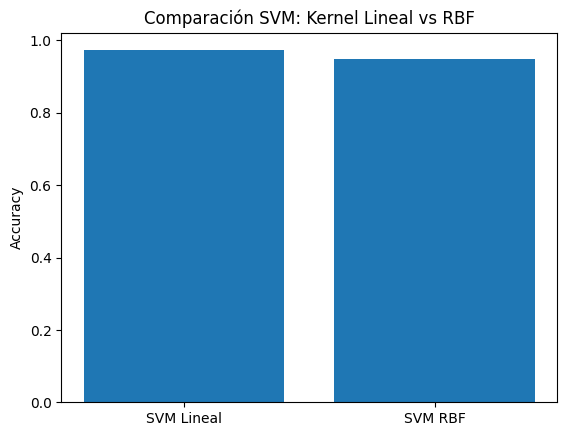

In [25]:
# Faster SVM comparison using a smaller subset to avoid timeout
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv('SMA.csv')

# Use a subset (sample) for speed
df_sample = df.sample(frac=0.5, random_state=42)

X = df_sample.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df_sample["SMA_Scale (Class_Lebel)"]

# Pipelines
svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='linear'))
])

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf'))
])

# Cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores_linear = cross_val_score(svm_linear, X, y, cv=cv, scoring='accuracy')
scores_rbf = cross_val_score(svm_rbf, X, y, cv=cv, scoring='accuracy')

means = [scores_linear.mean(), scores_rbf.mean()]
labels = ["SVM Lineal", "SVM RBF"]

# Plot
plt.figure()
plt.bar(labels, means)
plt.ylabel("Accuracy")
plt.title("Comparación SVM: Kernel Lineal vs RBF")
plt.show()

## Regularización

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Escalar datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# L2 (Ridge)
model_l2 = LogisticRegression(l1_ratio=0, C=1.0, max_iter=2000)
model_l2.fit(X_train_scaled, y_train)

# L1 (Lasso)
model_l1 = LogisticRegression(l1_ratio=1, solver='saga', C=1.0)
model_l1.fit(X_train_scaled, y_train)

c:\Users\oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score

# ==========================
# 1. Cargar datos
# ==========================
df = pd.read_csv("SMA.csv")

# ==========================
# 2. Preparar datos
# ==========================
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# ==========================
# 3. Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================
# 4. Escalado
# ==========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# 5. RIDGE
# ==========================
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

# Convertir predicciones continuas a clases
ridge_pred_class = np.round(ridge_pred)

# Accuracy
ridge_acc = accuracy_score(y_test, ridge_pred_class)

print("Accuracy Ridge:", ridge_acc)

# ==========================
# 6. LASSO
# ==========================
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

# Convertir a clases
lasso_pred_class = np.round(lasso_pred)

# Accuracy
lasso_acc = accuracy_score(y_test, lasso_pred_class)

print("Accuracy Lasso:", lasso_acc)

Accuracy Ridge: 0.970873786407767
Accuracy Lasso: 0.8543689320388349


<Axes: >

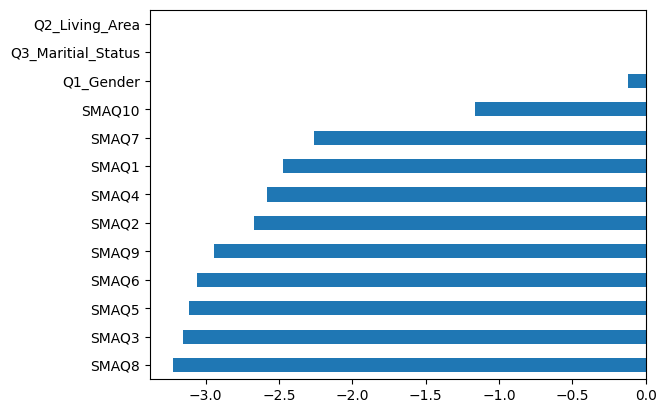

In [27]:
import pandas as pd

coef = pd.Series(model_l1.coef_[0], index=X.columns)
coef.sort_values().plot(kind="barh")

## Ensembles - Gradient Boosting

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Ada Boost

In [29]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier()
model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [30]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Cargar datos
df = pd.read_csv("SMA.csv")

# Eliminar variable con fuga de información
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# Definir validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  ## StratifiedKFold para mantener proporcionalidad de clases
    ##shuffle=True para mezclar los datos, random_State: resultados reproducibles

# Modelos
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)

# Validación cruzada
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
gb_scores = cross_val_score(gb, X, y, cv=cv, scoring='accuracy')
ada_scores = cross_val_score(ada, X, y, cv=cv, scoring='accuracy')

# Resultados
print("Random Forest:", rf_scores)
print("Media RF:", rf_scores.mean())

print("\nGradient Boosting:", gb_scores)
print("Media GB:", gb_scores.mean())

print("\nAdaBoost:", ada_scores)
print("Media Ada:", ada_scores.mean())

Random Forest: [0.91747573 0.93203883 0.93203883 0.94174757 0.94146341]
Media RF: 0.9329528771015866

Gradient Boosting: [0.94660194 0.92718447 0.96116505 0.95631068 0.91707317]
Media GB: 0.9416670613308075

AdaBoost: [0.89805825 0.9223301  0.92718447 0.89320388 0.87317073]
Media Ada: 0.9027894861472887


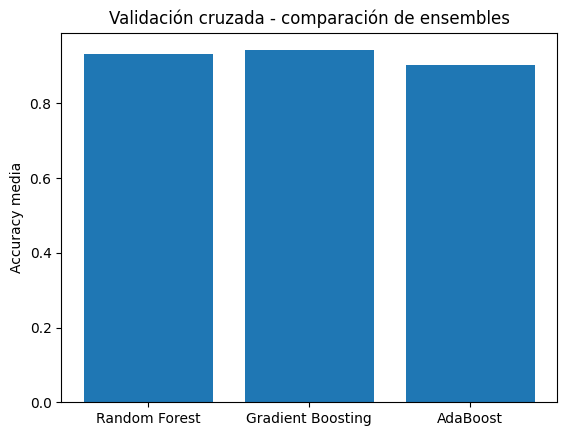

In [31]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Gradient Boosting", "AdaBoost"]
means = [rf_scores.mean(), gb_scores.mean(), ada_scores.mean()]

plt.figure()
plt.bar(models, means)
plt.ylabel("Accuracy media")
plt.title("Validación cruzada - comparación de ensembles")
plt.show()

## XGBoost

In [32]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Cargar datos
df = pd.read_csv("SMA.csv")

X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# Codificar clases
le = LabelEncoder()         ## transforma clases 0, 1, 2 en 1, 2 y 3.
y = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo
model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(set(y)),
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9466019417475728


In [33]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("Scores:", scores)
print("Media:", scores.mean())

Scores: [0.95631068 0.9368932  0.96116505 0.95631068 0.92682927]
Media: 0.9475017759886336


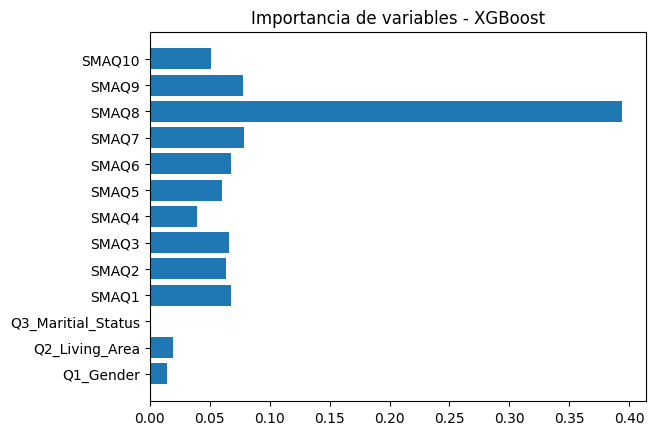

In [34]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(X.columns, importances)
plt.title("Importancia de variables - XGBoost")
plt.show()

## Regresion lineal

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.088615568805453


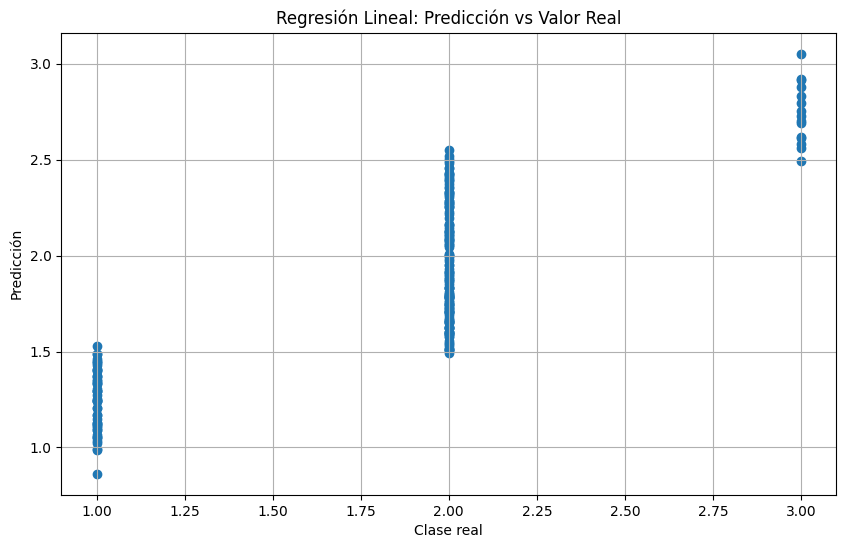

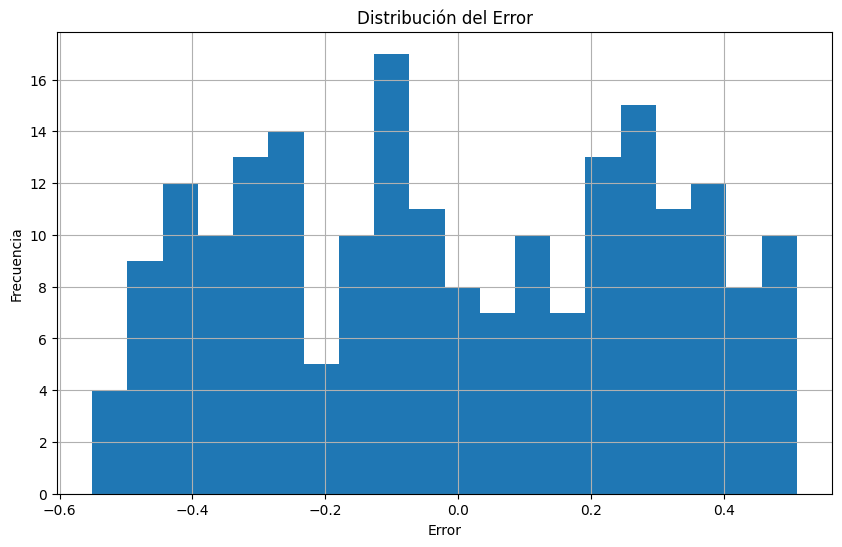

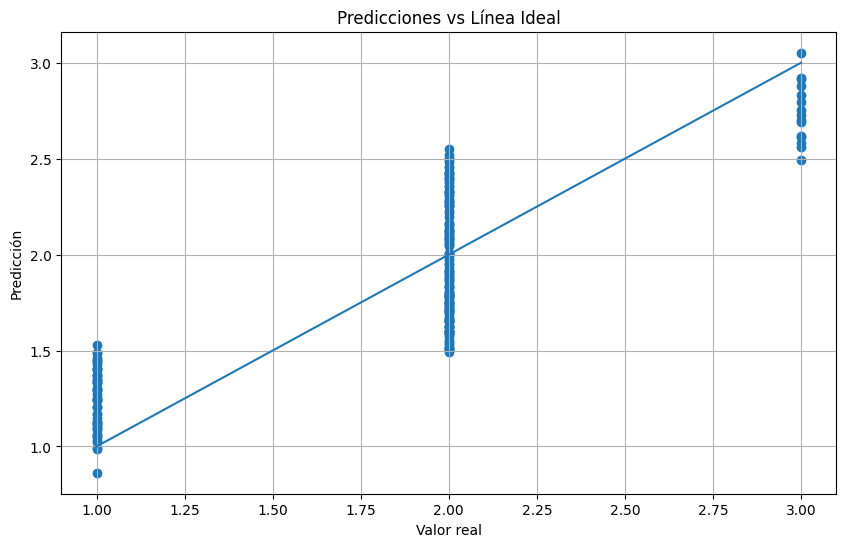

MSE: 0.088615568805453


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ==========================
# 1. Cargar dataset
# ==========================
df = pd.read_csv("SMA.csv")

# ==========================
# 2. Preparar datos
# (eliminamos fuga de información)
# ==========================
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# ==========================
# 3. Dividir datos
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================
# 4. Entrenar regresión lineal
# ==========================
model = LinearRegression()
model.fit(X_train, y_train)

# ==========================
# 5. Predicciones
# ==========================
y_pred = model.predict(X_test)

# ==========================
# GRÁFICA 1
# Predicción vs valor real
# ==========================
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Clase real")
plt.ylabel("Predicción")
plt.title("Regresión Lineal: Predicción vs Valor Real")

plt.grid(True)
plt.show()

# ==========================
# GRÁFICA 2
# Distribución del error
# ==========================
errors = y_test - y_pred

plt.figure(figsize=(10,6))
plt.hist(errors, bins=20)

plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución del Error")

plt.grid(True)
plt.show()

# ==========================
# GRÁFICA 3
# Línea ideal vs predicciones
# ==========================
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Predicciones vs Línea Ideal")

plt.grid(True)
plt.show()


print("MSE:", mean_squared_error(y_test, y_pred))

## Regresion polinómica

In [37]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

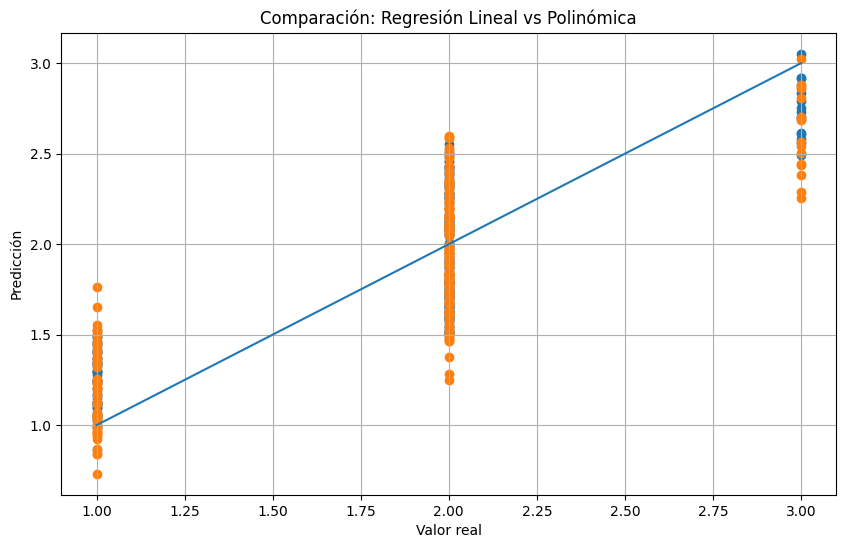

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# ==========================
# 1. Cargar datos
# ==========================
df = pd.read_csv("SMA.csv")

# ==========================
# 2. Preparar datos
# (eliminamos fuga de información)
# ==========================
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# ==========================
# 3. Dividir datos
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================
# 4. Modelo lineal
# ==========================
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# ==========================
# 5. Modelo polinómico
# ==========================
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

# ==========================
# 6. Gráfica comparativa
# ==========================
plt.figure(figsize=(10,6))

# Predicciones lineales
plt.scatter(y_test, y_pred_linear)

# Predicciones polinómicas
plt.scatter(y_test, y_pred_poly)

# Línea ideal (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Comparación: Regresión Lineal vs Polinómica")

plt.grid(True)
plt.show()

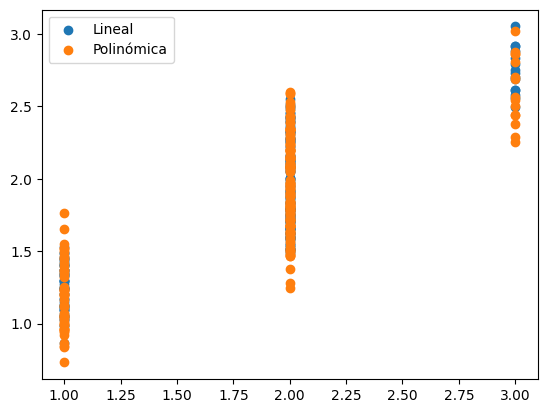

In [39]:
plt.scatter(y_test, y_pred_linear, label="Lineal")
plt.scatter(y_test, y_pred_poly, label="Polinómica")
plt.legend()

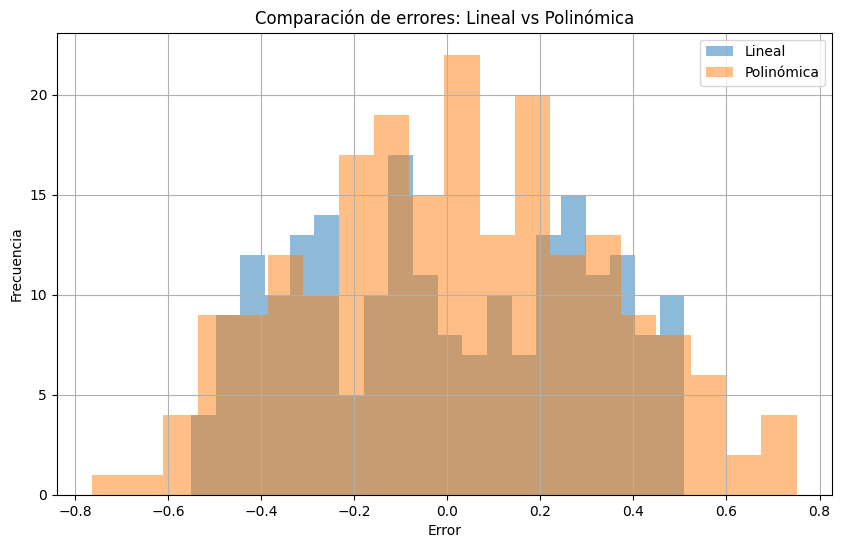

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# ==========================
# 1. Cargar datos
# ==========================
df = pd.read_csv("SMA.csv")

# ==========================
# 2. Preparar datos
# ==========================
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# ==========================
# 3. Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================
# 4. Modelos
# ==========================
# Lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Polinómico
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

# ==========================
# 5. Cálculo de errores
# ==========================
error_linear = y_test - y_pred_linear
error_poly = y_test - y_pred_poly

# ==========================
# 6. Gráfica comparativa
# ==========================
plt.figure(figsize=(10,6))

plt.hist(error_linear, bins=20, alpha=0.5, label="Lineal")
plt.hist(error_poly, bins=20, alpha=0.5, label="Polinómica")

plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Comparación de errores: Lineal vs Polinómica")

plt.legend()
plt.grid(True)
plt.show()

## LightGBM

In [41]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Cargar datos
df = pd.read_csv("SMA.csv")

# Preparar datos (sin fuga)
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]

# IMPORTANTE: ajustar clases (0,1,2)
y = y - 1

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    random_state=42
)

# Entrenar
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 823, number of used features: 13
[LightGBM] [Info] Start training from score -1,389946
[LightGBM] [Info] Start training from score -0,385019
[LightGBM] [Info] Start training from score -2,652513
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [43]:
## validación cruzada

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("Scores:", scores)
print("Media:", scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 823, number of used features: 13
[LightGBM] [Info] Start training from score -1,389946
[LightGBM] [Info] Start training from score -0,386807
[LightGBM] [Info] Start training from score -2,635419
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

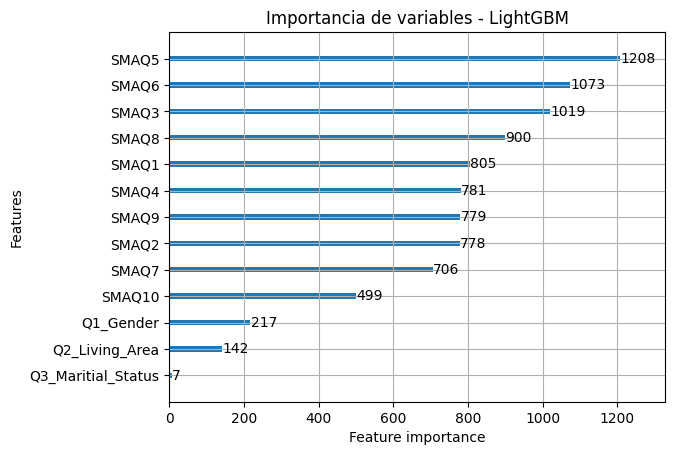

In [44]:
## importancia de variables

import matplotlib.pyplot as plt

lgb.plot_importance(model)
plt.title("Importancia de variables - LightGBM")
plt.show()

## KNN

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# 1. Cargar dataset
df = pd.read_csv("SMA.csv")

# 2. Preparar datos
X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]


# 3. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
# 4. Escalado
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Modelo KNN, con K=5
knn = KNeighborsClassifier(n_neighbors=5)

# 6. Entrenar
knn.fit(X_train, y_train)

# 7. Predicción
y_pred = knn.predict(X_test)

# 8. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.912621359223301


c:\Users\oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:19:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:19:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:19:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:19:45] WARNING: C:\actio

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 823, number of used features: 13
[LightGBM] [Info] Start training from score -1,389946
[LightGBM] [Info] Start training from score -0,386807
[LightGBM] [Info] Start training from score -2,635419
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

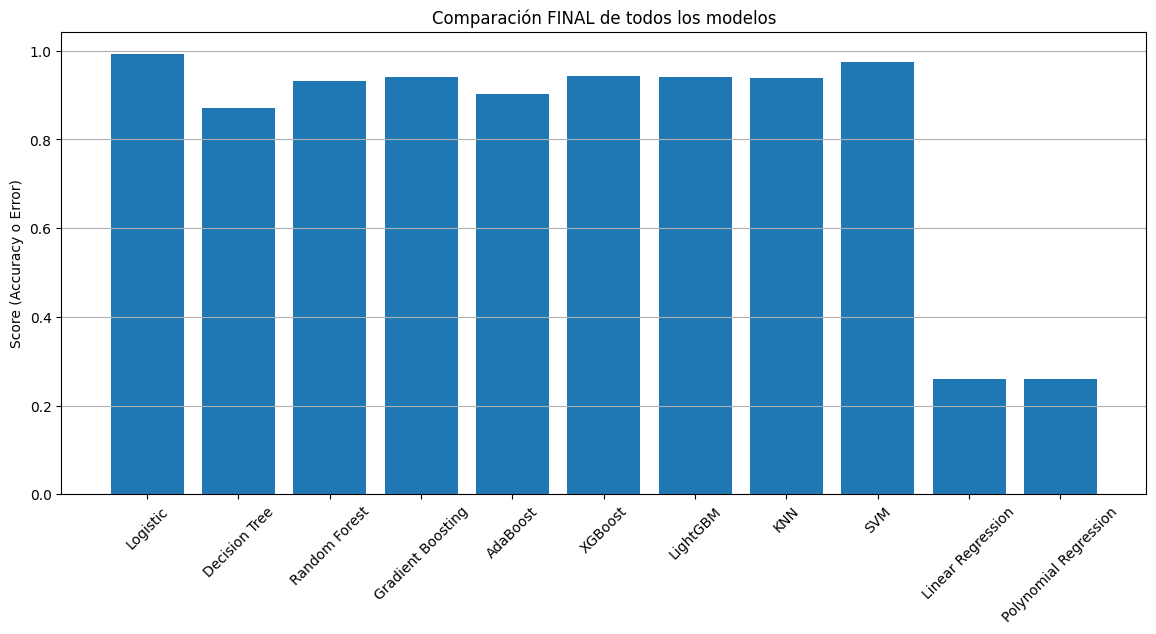

In [45]:
## comparacion gráfica de todos los métodos




import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, accuracy_score

import lightgbm as lgb
from xgboost import XGBClassifier

# ==========================
# 1. Cargar datos
# ==========================
df = pd.read_csv("SMA.csv")

X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"]
y_encoded = y - 1  # para modelos tipo boosting

# ==========================
# 2. Validación cruzada
# ==========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================
# 3. Modelos de clasificación
# ==========================
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        n_estimators=50,
        use_label_encoder=False
    ),
    "LightGBM": lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        n_estimators=50
    ),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
}

results = {}

# ==========================
# 4. Evaluar modelos clasificación
# ==========================
for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=cv, scoring='accuracy')
    results[name] = scores.mean()

# ==========================
# 5. Regresión lineal (adaptada)
# ==========================
lin_model = LinearRegression()
lin_scores = cross_val_score(
    lin_model, X, y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)
results["Linear Regression"] = -lin_scores.mean()

# ==========================
# 6. Regresión polinómica
# ==========================
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_scores = cross_val_score(
    poly_model, X, y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)
results["Polynomial Regression"] = -poly_scores.mean()

# ==========================
# 7. Gráfico final
# ==========================
plt.figure(figsize=(14,6))

plt.bar(results.keys(), results.values())

plt.xticks(rotation=45)
plt.ylabel("Score (Accuracy o Error)")
plt.title("Comparación FINAL de todos los modelos")

plt.grid(axis='y')
plt.show()

## Predecir casos nuevos

In [46]:
import pandas as pd
import lightgbm as lgb                  ## usando LightGBM

# Cargar datos
df = pd.read_csv("SMA.csv")

X = df.drop(columns=["SMA_Scale (Class_Lebel)", "SMA_Scale_value"])
y = df["SMA_Scale (Class_Lebel)"] - 1  # importante

# Modelo final
model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=100,
    random_state=42
)

# Entrenar con TODOS los datos
model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 1029, number of used features: 13
[LightGBM] [Info] Start training from score -1,387267
[LightGBM] [Info] Start training from score -0,386692
[LightGBM] [Info] Start training from score -2,645883
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [47]:
## nuevo caso de SMA

nuevo_caso = pd.DataFrame([{
    "Q1_Gender": 1,
    "Q2_Living_Area": 2,
    "Q3_Maritial_Status": 1,
    "SMAQ1": 3,
    "SMAQ2": 4,
    "SMAQ3": 2,
    "SMAQ4": 5,
    "SMAQ5": 3,
    "SMAQ6": 5,
    "SMAQ7": 5,
    "SMAQ8": 5,
    "SMAQ9": 4,
    "SMAQ10": 5
}])

In [48]:
pred = model.predict(nuevo_caso)

# Volver a etiquetas originales
pred_clase = pred[0] + 1

print("Clase predicha:", pred_clase)

Clase predicha: 3


In [49]:
proba = model.predict_proba(nuevo_caso)

print("Probabilidades:", proba)         ## tanto por uno de prob de ser clase 1, 2 y 3

Probabilidades: [[2.04957473e-04 2.48636840e-01 7.51158202e-01]]


In [50]:
## guardar modelo

import joblib
joblib.dump(model, "modelo_sma.pkl")

['modelo_sma.pkl']

In [51]:
## cargar modelo

model = joblib.load("modelo_sma.pkl")